In [134]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [135]:
df = pd.read_csv('Exam_2026_Problem2.txt', sep=' ', header=1, names=['azimuth', 'zenith'])
df

,azimuth,zenith
0,1.128,1.995
1,1.426,1.199
2,2.901,0.807
3,2.925,2.571
4,0.607,2.629
...,...,...
134,1.775,1.241
135,1.733,0.962
136,1.625,1.382
137,0.895,2.351


In [136]:
azimuth = df['azimuth'].values
zenith = df['zenith'].values

## a)

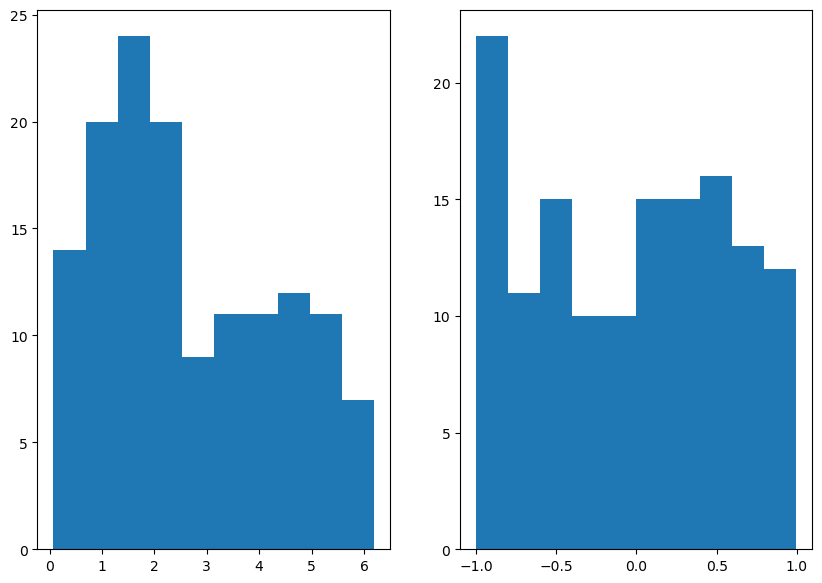

In [137]:
fig, ax = plt.subplots(1, 2, figsize=(10,7))
ax[0].hist(azimuth)
ax[1].hist(np.cos(zenith));

In [138]:
def isotropicSampler(seed, Npoints):
    np.random.seed(seed)                       
    samplAzi = np.random.uniform(0, 2 * np.pi, Npoints)
    samplCosZen = np.random.uniform(-1, 1, Npoints)
    samplZen = np.arccos(samplCosZen)
    return samplAzi, samplZen
                        
samplAzi, samplZen = isotropicSampler(42, len(azimuth))

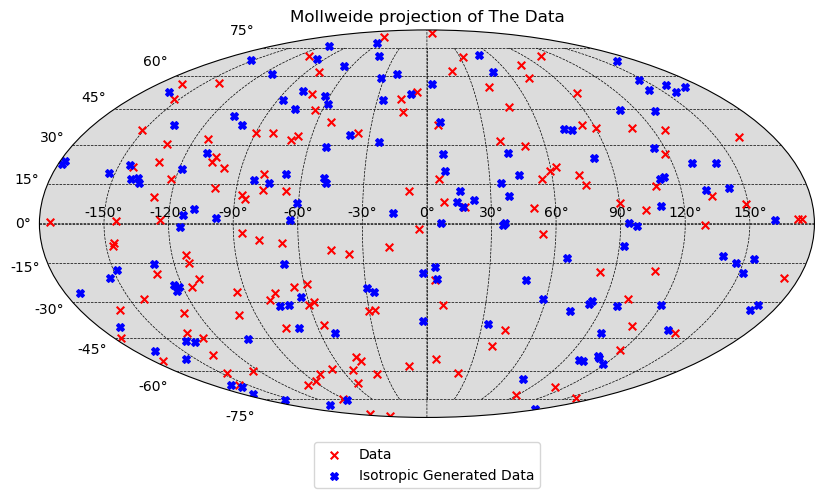

In [139]:
fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = {'projection': 'mollweide'})
ax.set_facecolor('gainsboro')
ax.grid(color = 'black', linestyle = '--', linewidth = 0.5)

meridian = np.stack([np.zeros(100), np.linspace(0, np.pi, 100) - np.pi / 2], axis = 1)
equator = np.stack([np.linspace(0, 2 * np.pi, 100) - np.pi, np.zeros(100)], axis = 1)

ax.plot(meridian[:,0], meridian[:,1], color = 'black', linestyle = '--', linewidth = 0.5)
ax.plot(equator[:,0], equator[:,1], color = 'black', linestyle = '--', linewidth = 0.5)

ax.scatter(azimuth - np.pi, -zenith + np.pi / 2, marker = 'x', color = 'red', s = 30, zorder = 2, label = 'Data')
ax.scatter(samplAzi - np.pi, -samplZen + np.pi / 2, marker = 'X', color = 'blue', s = 30, zorder = 2, label = 'Isotropic Generated Data')
ax.set_title("Mollweide projection of The Data")
    

ax.legend(loc = 'lower center', bbox_to_anchor = (0.5, -0.2),);

In [140]:
def twoPointCorrFunc(azimuth, zenith, bins):
    Npoints = len(azimuth)

    x = np.cos(azimuth) * np.sin(zenith)
    y = np.sin(azimuth) * np.sin(zenith)
    z = np.cos(zenith) 

    cosPhiBins = np.linspace(-1, 1, bins)

    cosPhi_ijVals = []

    for i in range(0, Npoints):
        for j in range(0, i):
            cosPhi_ij = x[i] * x[j] + y[i] * y[j] + z[i] * z[j]
            cosPhi_ijVals.append(cosPhi_ij)

    y_values = []

    for i in range(bins):
        heaviside = np.heaviside(cosPhi_ijVals - cosPhiBins[i], 0)
        two_point = (2 / (Npoints * (Npoints - 1))) * np.sum(heaviside)  
        y_values.append(two_point)


    prediction_iso = 1/2 * (1 - cosPhiBins)

    return cosPhiBins, y_values, prediction_iso

In [141]:
x, y, predictionIso = twoPointCorrFunc(azimuth, zenith, 1000)
xSampl, ySampl, predictionIsoSampl = twoPointCorrFunc(samplAzi, samplZen, 1000)

In [142]:
ksStatReal = np.max(np.abs(y - predictionIso))
print(f'KS-statistic for real data: {ksStatReal:.4f}')
ksStatSim = np.max(np.abs(ySampl- predictionIsoSampl))
print(f'KS-statistic for simulated data: {ksStatSim:.4f}')

KS-statistic for real data: 0.0226
KS-statistic for simulated data: 0.0086


In [187]:
Ntrials = 2000
Npoints = len(azimuth)
ksStatVals = []
for i in tqdm(range(Ntrials)):
    azi, zen = isotropicSampler(i, Npoints)
    x, y, predictIso = twoPointCorrFunc(azi, zen, 100)
    ksStat = np.max(np.abs(predictIso - y))
    ksStatVals.append(ksStat)

100%|██████████| 2000/2000 [01:36<00:00, 20.77it/s]


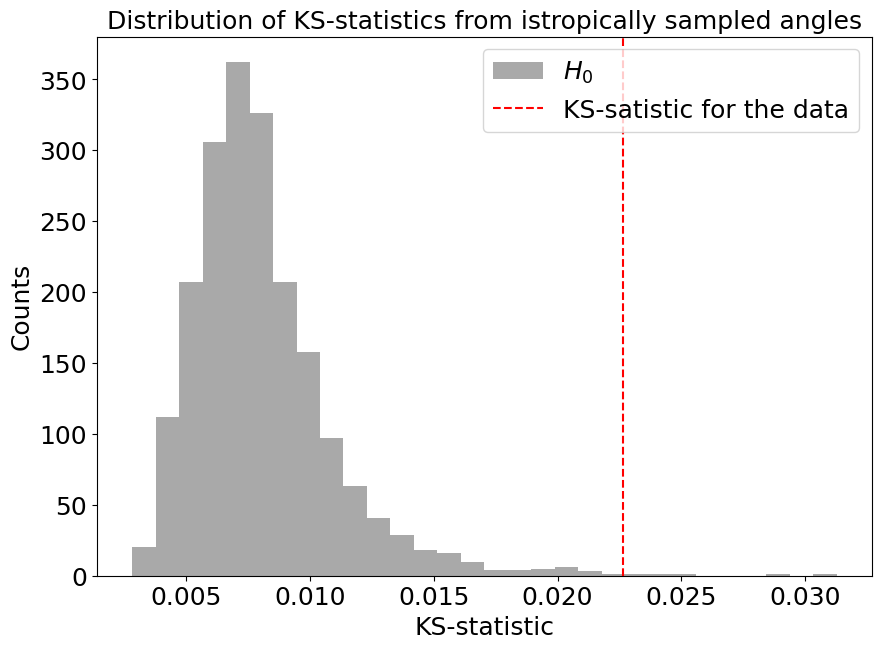

In [198]:
ksStatVals = np.array(ksStatVals)
fig, ax = plt.subplots(figsize=(10, 7))

xmin = np.min(ksStatVals)
xmax = np.max(ksStatVals)
Nbins = 30
ax.hist(ksStatVals, bins=Nbins, range=(xmin, xmax), color='darkgray', label=r'$H_0$')
ax.axvline(ksStatReal, color='red', linestyle='--', label='KS-satistic for the data')
ax.legend(fontsize=18);
ax.set_xlabel('KS-statistic', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Distribution of KS-statistics from istropically sampled angles', fontsize=18);
fig.savefig("2a.pdf");

In [197]:
from scipy.stats import norm
pVal = np.sum(ksStatVals >= ksStatReal) / Ntrials
print(f'p-value: {pVal:.4f}')
z = norm.ppf(1 - pVal/2)
print(z)

p-value: 0.0025
3.0233414397391543


## b)

In [190]:
r = np.random

def Ha_gen(seed, Npoints):
    r.seed(seed)

    Ninit = int(0.2 * Npoints)
    
    initAzi = r.uniform(0.225*np.pi, 0.725*np.pi, Ninit)
    initZen = r.uniform(-1, 0, Ninit)

    isoAzi= r.uniform(0, 2 * np.pi, Npoints - Ninit)
    isoCosZen = r.uniform(-1, 1, Npoints - Ninit)
    isoZen = np.arccos(isoCosZen)

    azi = np.concatenate((initAzi, isoAzi))
    zen = np.concatenate((initZen, isoZen))

    return azi, zen

def Hb_gen(seed, Npoints):
    r.seed(seed)

    Ninit = int(0.15 * Npoints)
    
    initAzi = r.uniform(0*np.pi, 1*np.pi, Ninit)
    initZen = r.uniform(-1, 0, Ninit)

    isoAzi= r.uniform(0, 2 * np.pi, Npoints - Ninit)
    isoCosZen = r.uniform(-1, 1, Npoints - Ninit)
    isoZen = np.arccos(isoCosZen)

    azi = np.concatenate((initAzi, isoAzi))
    zen = np.concatenate((initZen, isoZen))

    return azi, zen

In [191]:
def ksStatHa(Ntrials, Npoints):
    ksStatVals = []
    for i in tqdm(range(Ntrials)):
        azi, zen = Ha_gen(i, Npoints)

        x, y, predictIso = twoPointCorrFunc(azi, zen, 100)
        ksStat = np.max(np.abs(predictIso - y))
        ksStatVals.append(ksStat)

    return ksStatVals

def ksStatHb(Ntrials, Npoints):
    ksStatVals = []
    for i in tqdm(range(Ntrials)):
        azi, zen = Hb_gen(i, Npoints)

        x, y, predictIso = twoPointCorrFunc(azi, zen, 100)
        ksStat = np.max(np.abs(predictIso - y))
        ksStatVals.append(ksStat)

    return ksStatVals

In [192]:
Ntrials = 2000
ksStatValsHa = ksStatHa(Ntrials, len(azimuth))
ksStatValsHb = ksStatHb(Ntrials, len(azimuth))

100%|██████████| 2000/2000 [01:33<00:00, 21.44it/s]


In [193]:
ksH0 = np.array(ksStatVals)
ksHa = np.array(ksStatValsHa)
ksHb = np.array(ksStatValsHb)

In [219]:
pHa = np.sum(ksH0 >= np.median(ksHa)) /  Ntrials
pHb = np.sum(ksH0 >= np.median(ksHb)) /  Ntrials

print(f'p-value Ha: {pHa:.4f} (considering isotropic data)')
print(f'p-value Hb: {pHb:.4f} (considering isotropic data)')

pHaReal = np.sum(ksHa >= ksStatReal) /  Ntrials
pHbReal = np.sum(ksHb >= ksStatReal) /  Ntrials

print(f'p-value Ha: {pHaReal:.4f} (considering real data)')
print(f'p-value Hb: {pHbReal:.4f} (considering real data)')

p-value Ha: 0.0005 (considering isotropic data)
p-value Hb: 0.0190 (considering isotropic data)
p-value Ha: 0.8360 (considering real data)
p-value Hb: 0.2250 (considering real data)


In [202]:
za = norm.ppf(1 - pHaReal/2)
zb = norm.ppf(1 - pHbReal/2)
print(za, zb)

0.2070126233851874 1.2133396224885171


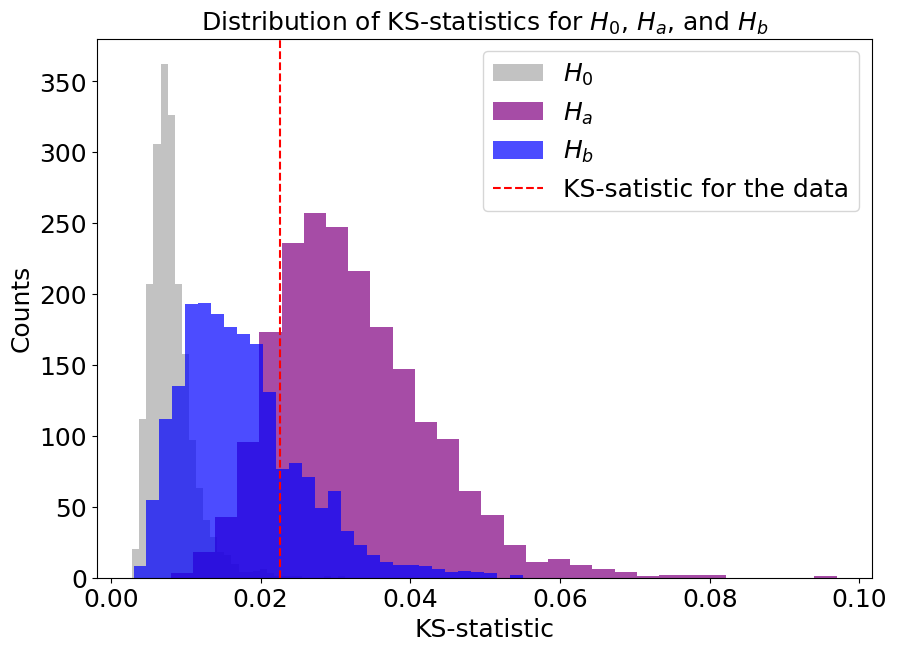

In [216]:
fig, ax = plt.subplots(figsize=(10, 7))

Nbins = 30
ax.hist(ksH0, bins=Nbins, color='darkgray', alpha=0.7, label=r'$H_0$')
ax.hist(ksHa, bins=Nbins, color='purple', alpha=0.7, label=r'$H_a$')
ax.hist(ksHb, bins=Nbins, color='blue', alpha=0.7, label=r'$H_b$')
ax.axvline(ksStatReal, color='red', linestyle='--', label='KS-satistic for the data')
ax.legend(fontsize=18);
ax.set_xlabel('KS-statistic', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.set_title('Distribution of KS-statistics for $H_0$, $H_a$, and $H_b$', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
fig.savefig("2b.pdf");